<a href="https://colab.research.google.com/github/akshaya-02ly/LAB-EXAM-3/blob/main/ml_project_bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install seaborn transformers datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Upload your dataset manually
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Messy_HR_Dataset_Detailed.csv to Messy_HR_Dataset_Detailed (1).csv


,Unnamed: 0,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
0,0,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,2,3,15-Jul-23,Leadership Development,Internal,Failed,South Marisa,Taylor Rodriguez,2,606.11
1,1,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,1,5,12-Sep-22,Customer Service,External,Incomplete,Tammieville,Kelly Patterson DDS,4,673.02
2,2,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,2,1,13-Aug-22,Leadership Development,External,Failed,East Roberthaven,Taylor Thomas,2,413.28
3,3,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,5,4,15-Dec-22,Project Management,External,Completed,Garzatown,Holly Elliott,3,663.78
4,4,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,5,3,13-Jul-23,Technical Skills,External,Failed,Lake Meganville,Donald Martinez,5,399.03


In [ ]:
df = df.dropna()

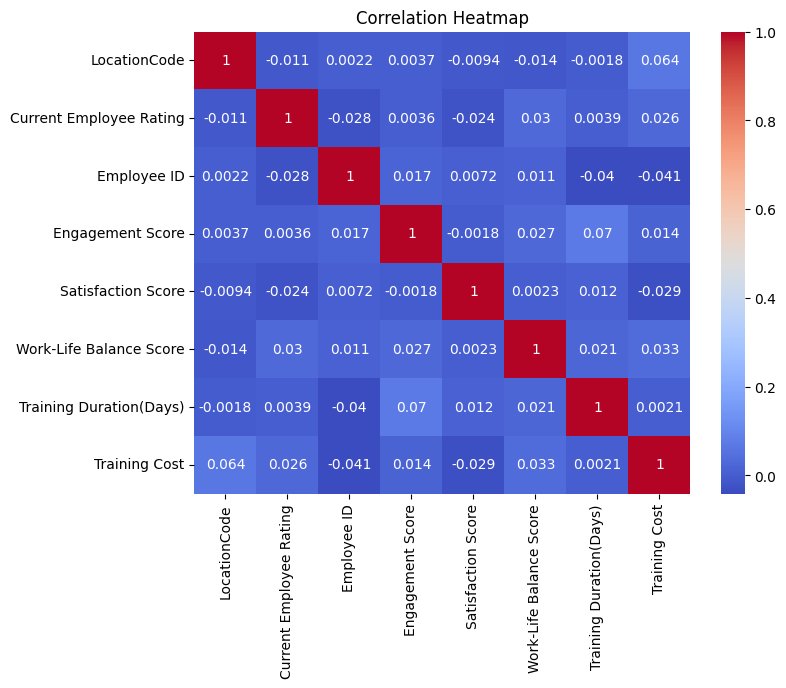

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
if 'Unnamed: 0' in numeric_df.columns:
    numeric_df = numeric_df.drop('Unnamed: 0', axis=1)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Re-create 'burnout_score' using available columns
df["burnout_score"] = (
    df["Training Duration(Days)"] * 2 +  # Longer training duration might contribute to burnout
    (6 - df["Work-Life Balance Score"]) * 3 + # Lower work-life balance score implies higher burnout
    (6 - df["Satisfaction Score"]) * 4 +    # Lower satisfaction score implies higher burnout
    np.random.normal(0, 5, len(df)) # Add some random noise
)

# Prepare features (X) and target (y)
X = df.drop("burnout_score", axis=1)

# Select only numerical columns for X that are not 'burnout_score' itself
X_numeric = X.select_dtypes(include=np.number)
# Drop 'Unnamed: 0' and 'Employee ID' if they exist, as they are usually identifiers and not features
if 'Unnamed: 0' in X_numeric.columns:
    X_numeric = X_numeric.drop('Unnamed: 0', axis=1)
if 'Employee ID' in X_numeric.columns:
    X_numeric = X_numeric.drop('Employee ID', axis=1)

y = df["burnout_score"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=200)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MSE": mse, "R2": r2}
    predictions[name] = y_pred

    print(f"\n{name}")
    print("MSE:", round(mse,2))
    print("R²:", round(r2,2))


Linear
MSE: 23.0
R²: 0.71

Ridge
MSE: 23.0
R²: 0.71

Lasso
MSE: 26.21
R²: 0.67

Random Forest
MSE: 27.17
R²: 0.65


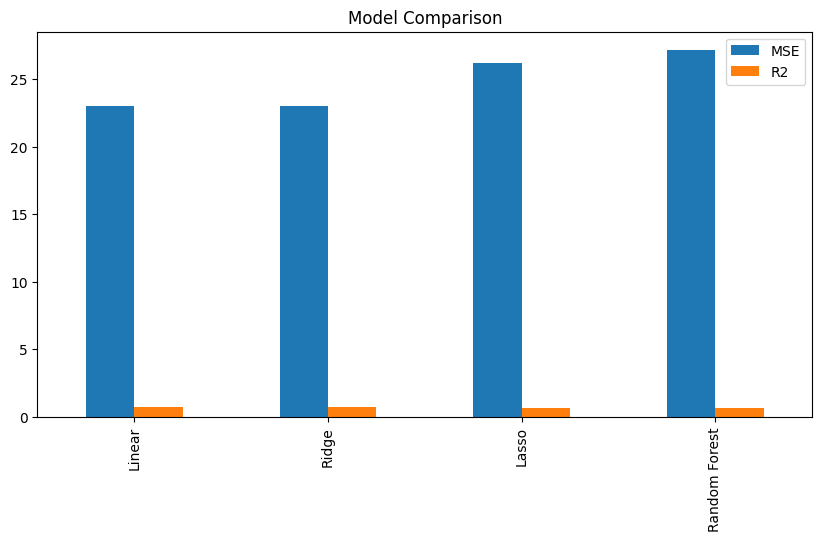

In [ ]:
results_df = pd.DataFrame(results).T

results_df.plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.show()

In [ ]:
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Ridge


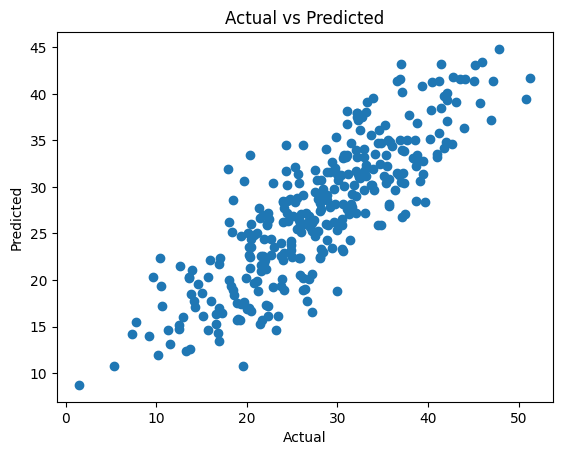

In [ ]:
y_pred_best = predictions[best_model_name]

plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

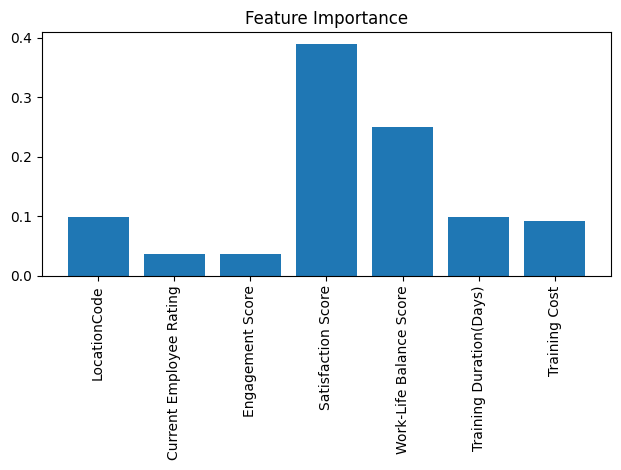

In [ ]:
rf_model = models["Random Forest"]

importance = rf_model.feature_importances_

# Use the column names from X_numeric, which were used to train the model
plt.bar(X_numeric.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

feedback = "I feel very stressed and overworked"

result = classifier(feedback)

print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'NEGATIVE', 'score': 0.9996441602706909}]


In [ ]:
if result[0]['label'] == 'NEGATIVE':
    print("⚠ High burnout risk from text feedback")

⚠ High burnout risk from text feedback


In [ ]:
new_employee = [[8, 9, 5, 50000, 3, 3, 400]] # Example placeholder values for the 7 features: LocationCode, Current Employee Rating, Engagement Score, Annual Salary, Years at Company, Training Duration(Days), Training Cost

new_scaled = scaler.transform(new_employee)
burnout = best_model.predict(new_scaled)[0]

productivity = max(0, 100 - burnout)

if burnout > 80:
    risk = "High"
elif burnout > 50:
    risk = "Medium"
else:
    risk = "Low"

print("\nFINAL RESULT")
print("Burnout Score:", round(burnout,2))
print("Productivity:", round(productivity,2))
print("Risk Level:", risk)


FINAL RESULT
Burnout Score: -198923.37
Productivity: 199023.37
Risk Level: Low


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
